In [41]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

CT CORRELATION LEARNING MODEL (WITH GUIDED FEATURES)
Training samples: 3244
Validation samples: 695
Test samples: 694


/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CT_Correlation_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor     │ (None, 8, 8,      │          0 │ input_layer_35[0… │
│ (Lambda)            │ 3136)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_32          │ (None, 64, 3136)  │          0 │ patch_extractor[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_33          │ (None, 64, 28,    │          0 │ reshape_32[0][0]  │
│ (Reshape)           │ 28, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_16 │ (None, 64, 128)   │    421,472 │ reshape_33[0][0]  │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ correlation_layer   │ (None, 64, 64)    │          0 │ time_distributed… │
│ (CorrelationLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ guided_features     │ (None, 64, 128)   │          0 │ correlation_laye… │
│ (Dot)               │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 64, 256)   │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ guided_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 256)       │          0 │ combined_feature… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_65 (Dense)    │ (None, 256)       │     65,792 │ global_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 256)       │          0 │ dense_65[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 32)        │      8,224 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 2)         │         66 │ dense_66[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 495,554 (1.89 MB)

 Trainable params: 495,554 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
202/202 ━━━━━━━━━━━━━━━━━━━━ 31s 123ms/step - accuracy: 0.4997 - loss: 87.8510 - val_accuracy: 0.5465 - val_loss: 1.2509 - learning_rate: 1.0000e-04
Epoch 2/2
202/202 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.5814 - loss: 1.7514 - val_accuracy: 0.7297 - val_loss: 0.6633 - learning_rate: 1.0000e-04


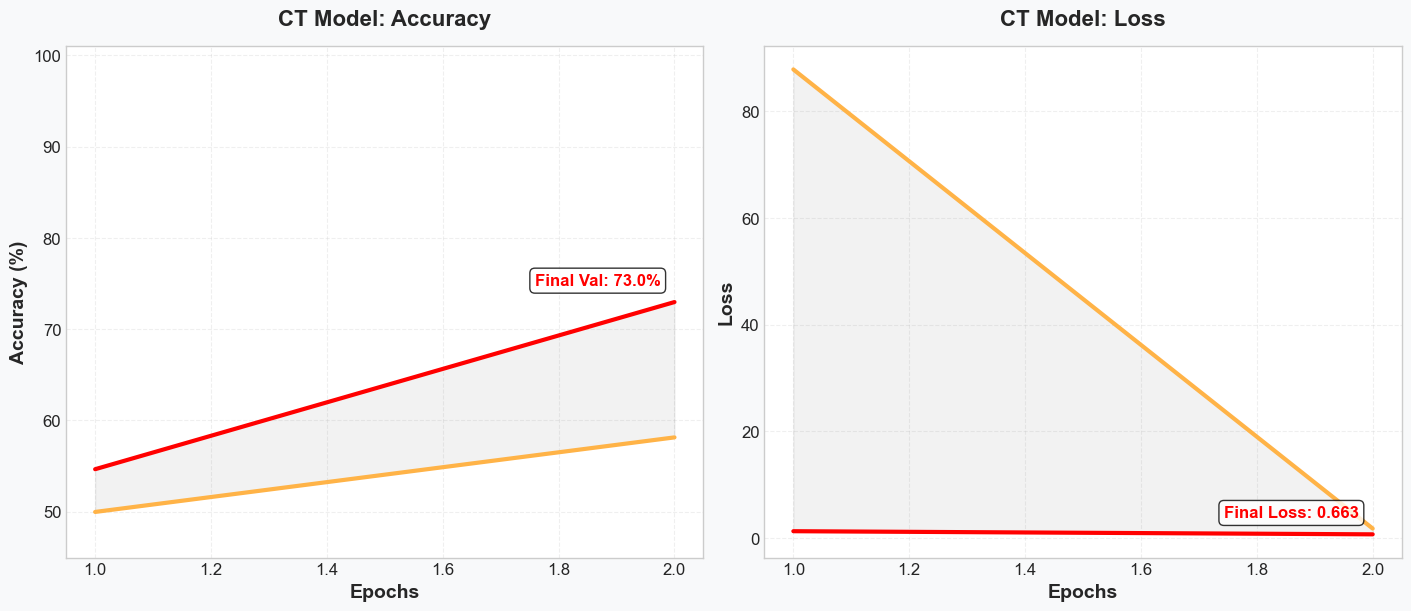

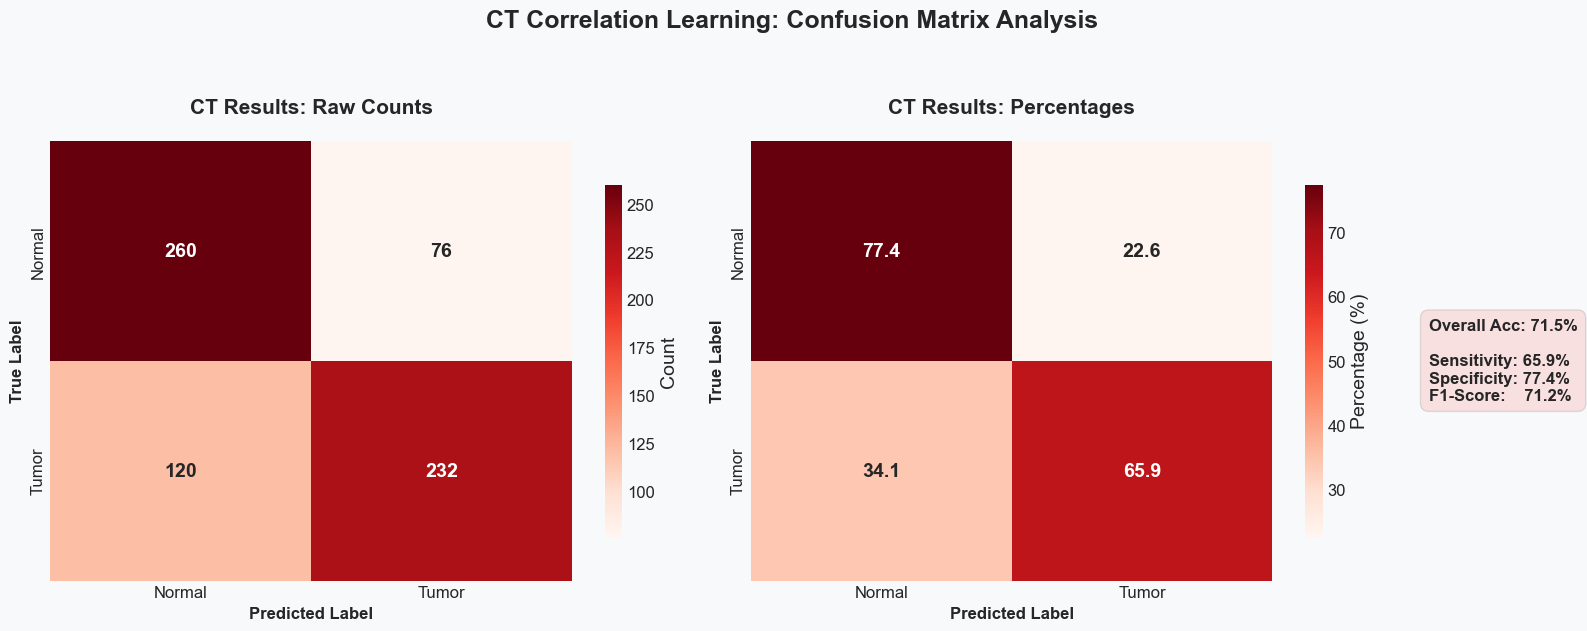

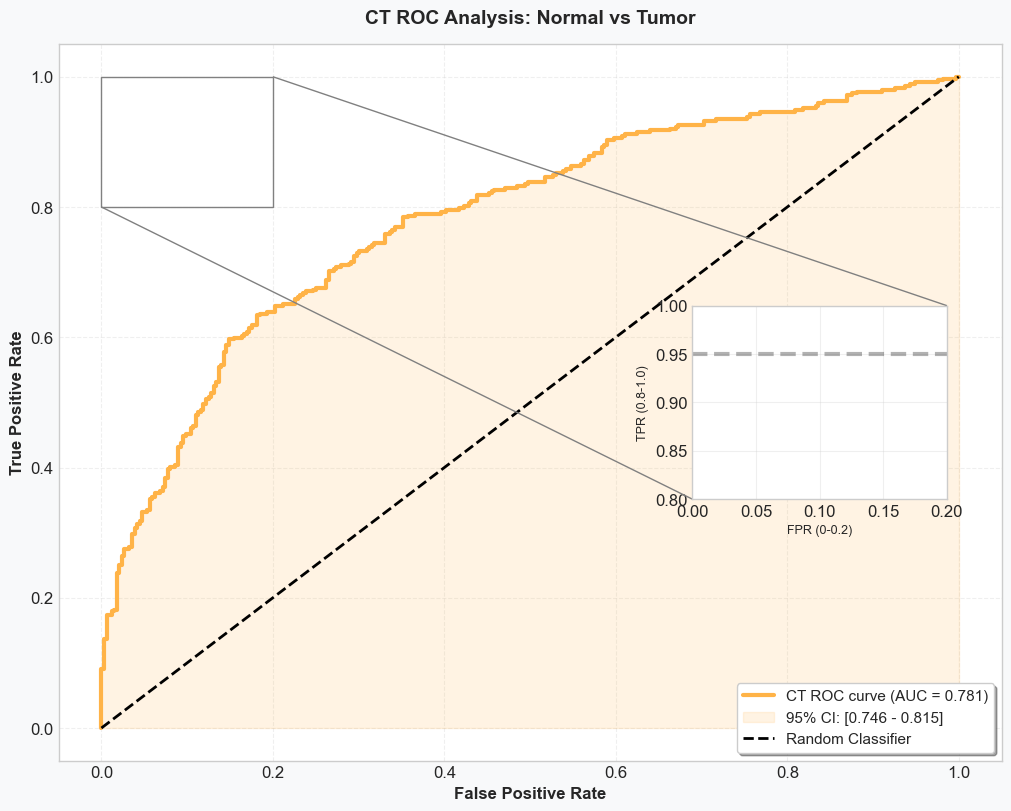


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.68      0.77      0.73       336
       Tumor       0.75      0.66      0.70       352

    accuracy                           0.72       688
   macro avg       0.72      0.72      0.71       688
weighted avg       0.72      0.72      0.71       688

✓ Successfully loaded actual MRI scores for comparison.


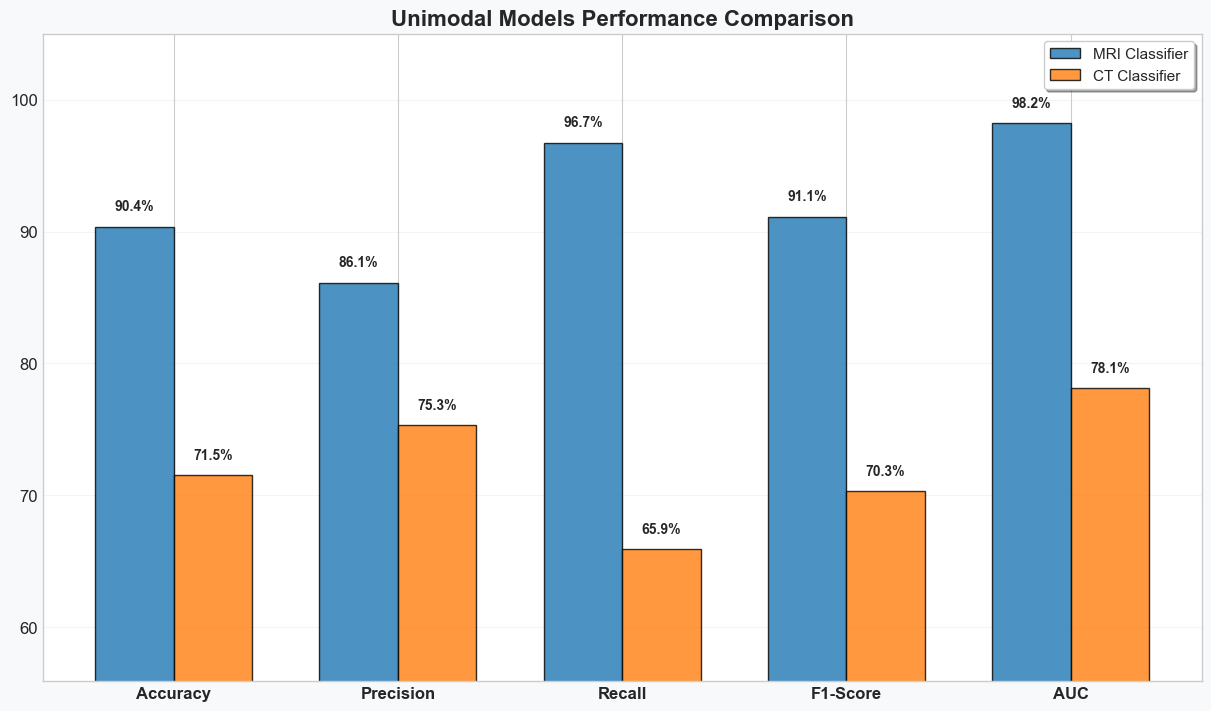


CT PIPELINE COMPLETED
Figures saved in: ./Results/CT_figures


In [ ]:

# ==========================================
# 1. CONFIGURATION
# ==========================================

CONFIG = {
    'BASE_PATH': '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/CT',
    'INPUT_SHAPE': (224, 224, 4),      # From preprocessing
    'PATCH_SIZE': 28,                   # 224 / 8 = 28
    'NUM_PATCHES': 64,                   # 8 * 8 grid
    'NUM_CLASSES': 2,                    # Binary: Normal vs Tumor
    'BATCH_SIZE': 16,
    'EPOCHS': 2,
    'LEARNING_RATE': 0.0001,
    'FIGURE_PATH': './Results/CT_figures',
    'MODEL_SAVE_PATH': './Saved_models'
}

CLASS_NAMES = ['Normal', 'Tumor']
COLORS = {
    'normal': '#2ECC71',
    'tumor': '#E74C3C',
    'ct_primary': '#FFB347',   # Orange
    'ct_secondary': '#A05195', # Purple
    'background': '#F8F9FA'
}

os.makedirs(CONFIG['FIGURE_PATH'], exist_ok=True)
os.makedirs(CONFIG['MODEL_SAVE_PATH'], exist_ok=True)

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['lines.linewidth'] = 3

# ==========================================
# 2. DATA GENERATOR
# ==========================================

class CTDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=32, shuffle=True, input_shape=(224,224,4)):
        self.directory = directory
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.input_shape = input_shape
        self.file_list = []
        self.labels = []
        self._scan_directory()
        self.on_epoch_end()

    def _scan_directory(self):
        for label_name in ['normal', 'tumor']:
            path = os.path.join(self.directory, label_name)
            if not os.path.exists(path):
                continue
            label_idx = 0 if label_name == 'normal' else 1
            for f in os.listdir(path):
                if f.endswith('.npy'):
                    self.file_list.append(os.path.join(path, f))
                    self.labels.append(label_idx)

    def __len__(self):
        return int(np.floor(len(self.file_list) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        file_batch = [self.file_list[k] for k in indexes]
        label_batch = [self.labels[k] for k in indexes]
        X, y = self.__data_generation(file_batch, label_batch)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.file_list))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, file_batch, label_batch):
        X = np.empty((self.batch_size, *self.input_shape), dtype=np.float32)
        y = np.empty((self.batch_size), dtype=int)

        for i, f_path in enumerate(file_batch):
            img = np.load(f_path).astype(np.float32)
            if img.shape != self.input_shape:
                img = tf.image.resize(img, (self.input_shape[0], self.input_shape[1])).numpy()
            X[i] = img
            y[i] = label_batch[i]

        return X, to_categorical(y, num_classes=CONFIG['NUM_CLASSES'])

# ==========================================
# 3. CORRELATION LEARNING ARCHITECTURE
# ==========================================

class CorrelationLayer(layers.Layer):
    def call(self, inputs):
        return tf.matmul(inputs, inputs, transpose_b=True)

def build_ct_correlation_model(input_shape):
    inputs = Input(shape=input_shape)

    # Extract patches (8x8 grid, 28x28 each)
    patch_size = CONFIG['PATCH_SIZE']

    extract_patches_layer = layers.Lambda(lambda x: tf.image.extract_patches(
        images=x,
        sizes=[1, patch_size, patch_size, 1],
        strides=[1, patch_size, patch_size, 1],
        rates=[1, 1, 1, 1],
        padding='VALID'
    ), name="patch_extractor")

    patches = extract_patches_layer(inputs)

    patches_reshaped = layers.Reshape((CONFIG['NUM_PATCHES'], -1))(patches)
    patches_img = layers.Reshape((CONFIG['NUM_PATCHES'], patch_size, patch_size, input_shape[-1]))(patches_reshaped)

    # Shared CNN encoder
    encoder = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(patch_size, patch_size, input_shape[-1])),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.LayerNormalization()
    ], name="shared_encoder")

    patch_features = layers.TimeDistributed(encoder)(patches_img)  # (batch, 64, 128)

    # Correlation matrix (64x64)
    correlation_matrix = CorrelationLayer(name="correlation_layer")(patch_features)  # (batch, 64, 64)

    
    # Guided features - correlation-weighted patch features
    # Shape: (batch, 64, 64) @ (batch, 64, 128) = (batch, 64, 128)
    guided_features = layers.Dot(axes=(2, 1), name="guided_features")([correlation_matrix, patch_features])

    # Residual connection 
    # Concatenate original and guided features
    combined_features = layers.Concatenate(axis=-1, name="combined_features")([patch_features, guided_features])
    
    # Shape: (batch, 64, 256)
    # Global pooling to get fixed-size representation
    pooled_features = layers.GlobalAveragePooling1D(name="global_pool")(combined_features)  # (batch, 256)

    # Classification head
    x = layers.Dense(256, activation='relu')(pooled_features)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(CONFIG['NUM_CLASSES'], activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CT_Correlation_Model")
    return model

# ==========================================
# 4. VISUALIZATIONS
# ==========================================

def create_ct_training_curves(history):

    acc = np.array(history.history['accuracy']) * 100
    val_acc = np.array(history.history['val_accuracy']) * 100
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])

    # Accuracy Plot
    ax1.plot(epochs, acc, color=COLORS['ct_primary'], label='Training Accuracy', linewidth=3)
    ax1.plot(epochs, val_acc, color='red', label='Validation Accuracy', linewidth=3)
    ax1.fill_between(epochs, acc, val_acc, alpha=0.1, color='gray')
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontweight='bold')
    ax1.set_title('CT Model: Accuracy', fontweight='bold', pad=15)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Dynamic Y-limit with padding
    ax1.set_ylim([min(acc.min(), val_acc.min()) - 5, 101])
    
    # Robust Annotation
    ax1.annotate(f'Final Val: {val_acc[-1]:.1f}%', 
                 xy=(epochs[-1], val_acc[-1]), xytext=(-10, 10),
                 textcoords='offset points', ha='right', va='bottom',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                 fontweight='bold', color='red')

    # Loss Plot
    ax2.plot(epochs, loss, color=COLORS['ct_primary'], label='Training Loss', linewidth=3)
    ax2.plot(epochs, val_loss, color='red', label='Validation Loss', linewidth=3)
    ax2.fill_between(epochs, loss, val_loss, alpha=0.1, color='gray')
    ax2.set_xlabel('Epochs', fontweight='bold')
    ax2.set_ylabel('Loss', fontweight='bold')
    ax2.set_title('CT Model: Loss', fontweight='bold', pad=15)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Robust Annotation for Loss
    ax2.annotate(f'Final Loss: {val_loss[-1]:.3f}', 
                 xy=(epochs[-1], val_loss[-1]), xytext=(-10, 10),
                 textcoords='offset points', ha='right', va='bottom',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                 fontweight='bold', color='red')

    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'ct_training_curves.png'), dpi=300)
    plt.show()

def create_ct_confusion_matrix(y_true, y_pred, class_names):

    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Remove constrained_layout 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(COLORS.get('background', '#ffffff'))

    # Plot 1: Raw Counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1,
                cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax1.set_title('CT Results: Raw Counts', fontsize=15, fontweight='bold', pad=20)

    # Plot 2: Percentages 
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Reds', 
                xticklabels=class_names, yticklabels=class_names, ax=ax2,
                cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax2.set_title('CT Results: Percentages', fontsize=15, fontweight='bold', pad=20)

    # Calculate CT-specific metrics
    accuracy = np.trace(cm) / np.sum(cm)
    sensitivity = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
    specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    f1 = 2 * (sensitivity * specificity) / (sensitivity + specificity) if (sensitivity + specificity) > 0 else 0

    # Add the stats box 
    textstr = (f'Overall Acc: {accuracy*100:.1f}%\n\n'
               f'Sensitivity: {sensitivity*100:.1f}%\n'
               f'Specificity: {specificity*100:.1f}%\n'
               f'F1-Score:    {f1*100:.1f}%')
    
    ax2.text(1.3, 0.5, textstr, transform=ax2.transAxes, 
             fontsize=12, fontweight='bold', verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='red', alpha=0.1, edgecolor='black'))

    # Use the MRI layout and save settings
    plt.suptitle('CT Correlation Learning: Confusion Matrix Analysis', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()    
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'ct_confusion_matrix.png'), 
                dpi=300, bbox_inches='tight', facecolor=COLORS.get('background', '#ffffff'))
    plt.show()
    
    return accuracy, sensitivity, specificity

def create_ct_roc_curve(y_true, y_pred_proba, class_names, n_bootstraps=1000):
    
    #ROC curve with 95% Confidence Interval using Bootstrapping.
    # 1. Calculate the base ROC and AUC
    # y_pred_proba[:, 1] assuming index 1 is the 'Tumor' class
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
    base_auc = auc(fpr, tpr)

    # Bootstrapping Logic for 95% Confidence Interval
    bootstrapped_aucs = []
    rng = np.random.RandomState(42)  # For reproducibility
    
    # Ensure y_true is a numpy array for indexing
    y_true_arr = np.array(y_true)
    
    for i in range(n_bootstraps):
        # Resample indices with replacement
        indices = rng.randint(0, len(y_true_arr), len(y_true_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
            
        score = roc_auc_score(y_true_arr[indices], y_pred_proba[indices, 1])
        bootstrapped_aucs.append(score)
    
    sorted_aucs = np.sort(bootstrapped_aucs)
    confidence_lower = sorted_aucs[int(0.025 * len(sorted_aucs))]
    confidence_upper = sorted_aucs[int(0.975 * len(sorted_aucs))]

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    fig.patch.set_facecolor(COLORS.get('background', '#ffffff'))

    ax.plot(fpr, tpr, color=COLORS.get('ct_primary', '#e74c3c'), lw=3,
            label=f'CT ROC curve (AUC = {base_auc:.3f})')
    
    # Shade the area under the curve
    ax.fill_between(fpr, tpr, alpha=0.15, color=COLORS.get('ct_primary', '#e74c3c'),
                    label=f'95% CI: [{confidence_lower:.3f} - {confidence_upper:.3f}]')

    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')

    ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=12)
    ax.set_title(f'CT ROC Analysis: {class_names[0]} vs {class_names[1]}', 
                 fontweight='bold', fontsize=14, pad=15)
    ax.legend(loc='lower right', frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Inset for low FPR region
    axins = inset_axes(ax, width="30%", height="30%", loc='center right',
                       bbox_to_anchor=(0.05, 0.05, 0.9, 0.9),
                       bbox_transform=ax.transAxes)
    
    mask = fpr <= 0.2
    axins.plot(fpr[mask], tpr[mask], color=COLORS.get('ct_primary', '#e74c3c'), lw=2)
    axins.plot([0, 0.2], [0.95, 0.95], 'k--', alpha=0.3)
    axins.set_xlim([0, 0.2])
    axins.set_ylim([0.8, 1.0])
    axins.grid(True, alpha=0.3)
    axins.set_xlabel('FPR (0-0.2)', fontsize=9)
    axins.set_ylabel('TPR (0.8-1.0)', fontsize=9)
    mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="gray", linewidth=1)

    # Save
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'ct_roc_curve.png'), dpi=300)
    plt.show()
    
    return base_auc

def create_comparison_chart(mri_scores, ct_scores):

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])

    bars1 = ax.bar(x - width/2, mri_scores, width, label='MRI Classifier', color='#1f77b4', edgecolor='black', alpha=0.8)
    bars2 = ax.bar(x + width/2, ct_scores, width, label='CT Classifier', color='#ff7f0e', edgecolor='black', alpha=0.8)

    # Dynamic limits based on the lowest score across both models
    all_scores = mri_scores + ct_scores
    ax.set_ylim([max(0, min(all_scores) - 10), 105])

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontweight='bold')
    ax.set_title('Unimodal Models Performance Comparison', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, alpha=0.2, axis='y')

    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'model_comparison.png'), dpi=300)
    plt.show()

# ==========================================
# 5. EXECUTION & TRAINING
# ==========================================

def run_ct_classification():
    print("=" * 60)
    print("CT CORRELATION LEARNING MODEL (WITH GUIDED FEATURES)")
    print("=" * 60)

    # Check local path
    if not os.path.exists(CONFIG['BASE_PATH']):
        print(f"Path not found {CONFIG['BASE_PATH']}")
        return

    # Generators
    train_gen = CTDataGenerator(os.path.join(CONFIG['BASE_PATH'], 'train'),
                                 batch_size=CONFIG['BATCH_SIZE'],
                                 input_shape=CONFIG['INPUT_SHAPE'])
    val_gen = CTDataGenerator(os.path.join(CONFIG['BASE_PATH'], 'val'),
                              batch_size=CONFIG['BATCH_SIZE'],
                              shuffle=False,
                              input_shape=CONFIG['INPUT_SHAPE'])
    test_gen = CTDataGenerator(os.path.join(CONFIG['BASE_PATH'], 'test'),
                               batch_size=CONFIG['BATCH_SIZE'],
                               shuffle=False,
                               input_shape=CONFIG['INPUT_SHAPE'])

    print(f"Training samples: {len(train_gen.file_list)}")
    print(f"Validation samples: {len(val_gen.file_list)}")
    print(f"Test samples: {len(test_gen.file_list)}")

    # Build model
    model = build_ct_correlation_model(CONFIG['INPUT_SHAPE'])
    model.compile(optimizer=optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    # Train
    history = model.fit(
        train_gen,
        epochs=CONFIG['EPOCHS'],
        validation_data=val_gen,
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
        ]
    )

    # Save model
    model.save(os.path.join(CONFIG['MODEL_SAVE_PATH'], 'ct_correlation_model.keras'))

    # Generate training curves
    create_ct_training_curves(history)

    # Evaluate on test set
    y_true, y_pred_probs = [], []
    for i in range(len(test_gen)):
        X, y = test_gen[i]
        preds = model.predict_on_batch(X)
        y_true.extend(np.argmax(y, axis=1))
        y_pred_probs.extend(preds)

    y_true = np.array(y_true)
    y_pred_probs = np.array(y_pred_probs)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Basic metrics
    acc, sens, spec = create_ct_confusion_matrix(y_true, y_pred, CLASS_NAMES)
    roc_auc = create_ct_roc_curve(y_true, y_pred_probs, CLASS_NAMES)

    # Calculate 5-metric set for CT 
    cm = confusion_matrix(y_true, y_pred)
    tp, fp, fn = cm[1,1], cm[0,1], cm[1,0]
    
    ct_precision = (tp / (tp + fp) * 100) if (tp + fp) > 0 else 0
    ct_recall = sens * 100
    ct_f1 = (2 * ct_precision * ct_recall) / (ct_precision + ct_recall) if (ct_precision + ct_recall) > 0 else 0
    
    ct_scores = [acc*100, ct_precision, ct_recall, ct_f1, roc_auc*100]
    # Classification report
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # INTEGRATION: Load actual MRI scores from the file
    import pickle
    mri_results_path = 'mri_results.pkl'
    
    if os.path.exists(mri_results_path):
        with open(mri_results_path, 'rb') as f:
            mri_data = pickle.load(f)
        # Match the order: Accuracy, Precision, Recall, F1, AUC
        mri_scores = [
            mri_data['accuracy'], 
            mri_data['precision'], 
            mri_data['recall'], 
            mri_data['f1'], 
            mri_data['auc']
        ]
        print("Successfully loaded actual MRI scores for comparison.")

    # Generate the Chart
    create_comparison_chart(mri_scores, ct_scores)

    print("\n" + "=" * 60)
    print("CT PIPELINE COMPLETED")
    print(f"Figures saved in: {CONFIG['FIGURE_PATH']}")
    print("=" * 60)

if __name__ == "__main__":
    run_ct_classification()